<a href="https://colab.research.google.com/github/sangramshitole07/AML/blob/main/AML_Preprocessing_Groceries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/Groceries_dataset (1).csv')
display(df.head())

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
display(df.head())
df.info()

,Member_number,Date,itemDescription
0,1808,2015-07-21,tropical fruit
1,2552,2015-01-05,whole milk
2,2300,2015-09-19,pip fruit
3,1187,2015-12-12,other vegetables
4,3037,2015-02-01,whole milk


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Member_number    38765 non-null  int64         
 1   Date             38765 non-null  datetime64[ns]
 2   itemDescription  38765 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 908.7+ KB


In [ ]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
display(df.head())

Number of duplicate rows: 759
Duplicate rows removed.


,Member_number,Date,itemDescription
0,1808,2015-07-21,tropical fruit
1,2552,2015-01-05,whole milk
2,2300,2015-09-19,pip fruit
3,1187,2015-12-12,other vegetables
4,3037,2015-02-01,whole milk


In [ ]:
print('Unique values in itemDescription before cleaning:')
print(df['itemDescription'].nunique())
print(df['itemDescription'].value_counts().head(10))

Unique values in itemDescription before cleaning:
167
itemDescription
whole milk          2363
other vegetables    1827
rolls/buns          1646
soda                1453
yogurt              1285
root vegetables     1041
tropical fruit      1014
bottled water        908
sausage              903
citrus fruit         795
Name: count, dtype: int64


In [ ]:
df['itemDescription'] = df['itemDescription'].str.lower().str.strip()
print('Unique values in itemDescription after cleaning:')
print(df['itemDescription'].nunique())
print(df['itemDescription'].value_counts().head(10))

Unique values in itemDescription after cleaning:
167
itemDescription
whole milk          2363
other vegetables    1827
rolls/buns          1646
soda                1453
yogurt              1285
root vegetables     1041
tropical fruit      1014
bottled water        908
sausage              903
citrus fruit         795
Name: count, dtype: int64


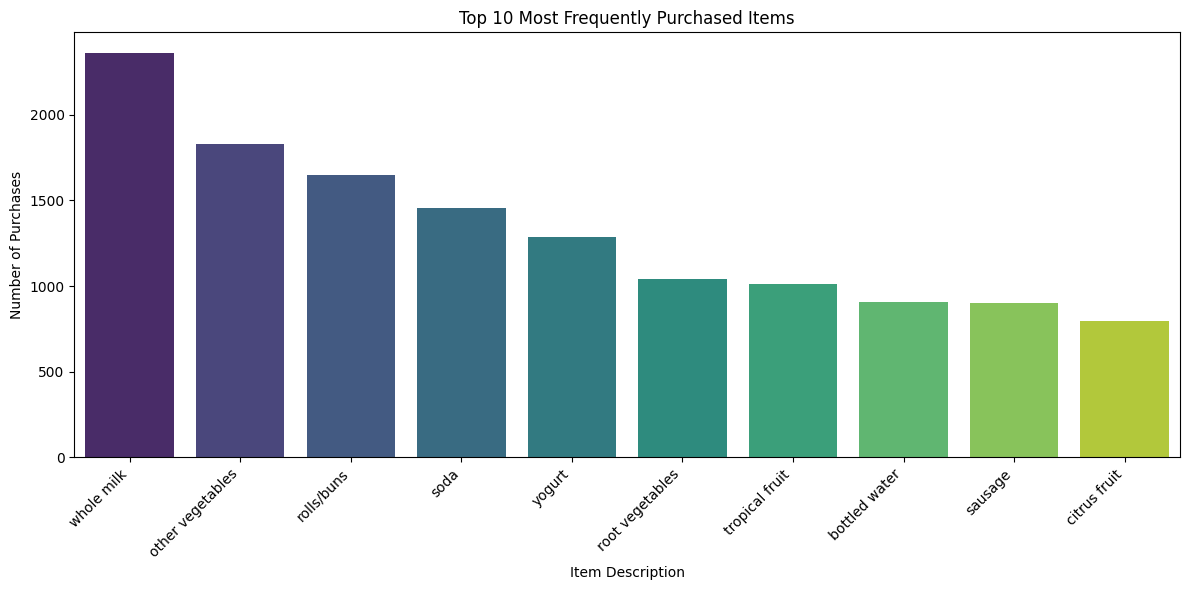

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_10_items = df['itemDescription'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_items.index, y=top_10_items.values, palette='viridis', hue=top_10_items.index, legend=False)
plt.title('Top 10 Most Frequently Purchased Items')
plt.xlabel('Item Description')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Label Encoding for 'itemDescription'
labelencoder_X = LabelEncoder()
df['itemDescription_encoded'] = labelencoder_X.fit_transform(df['itemDescription'])

display(df.head())

,Member_number,Date,itemDescription,itemDescription_encoded
0,1808,2015-07-21,tropical fruit,155
1,2552,2015-01-05,whole milk,164
2,2300,2015-09-19,pip fruit,108
3,1187,2015-12-12,other vegetables,101
4,3037,2015-02-01,whole milk,164


For One-Hot Encoding, we'll create a `ColumnTransformer`. This will apply `OneHotEncoder` to the `itemDescription` column and keep other columns as they are. Note that One-Hot Encoding can create a large number of new columns for categorical features with many unique values. Since `itemDescription` has 167 unique values, it will result in 167 new columns.

In [ ]:
import numpy as np

# Convert 'Date' to Unix timestamp (numerical) for compatibility
df['Date_timestamp'] = df['Date'].astype(np.int64) // 10**9 # Convert to seconds since epoch

# One-Hot Encoding for 'itemDescription'
# The ColumnTransformer will now work with numerical 'Member_number' and 'Date_timestamp'
ct = ColumnTransformer(
    [('item_description_ohe', OneHotEncoder(handle_unknown='ignore'), ['itemDescription'])],
    remainder='passthrough'
)

# Apply the ColumnTransformer on the relevant columns
X_encoded_array = ct.fit_transform(df[['Member_number', 'Date_timestamp', 'itemDescription']])

# Get feature names for the one-hot encoded columns
ohe_feature_names = ct.named_transformers_['item_description_ohe'].get_feature_names_out(['itemDescription'])

# The remainder columns are 'Member_number' and 'Date_timestamp' in their original order
remaining_features = ['Member_number', 'Date_timestamp']

# Combine all feature names
all_feature_names = list(ohe_feature_names) + remaining_features

# Convert to DataFrame and then to integer type as requested in your example
df_encoded = pd.DataFrame(X_encoded_array.toarray(), columns=all_feature_names)
df_encoded = df_encoded.astype(int)

display(df_encoded.head())
print(f"Shape of one-hot encoded DataFrame: {df_encoded.shape}")

,itemDescription_abrasive cleaner,itemDescription_artif. sweetener,itemDescription_baby cosmetics,itemDescription_bags,itemDescription_baking powder,itemDescription_bathroom cleaner,itemDescription_beef,itemDescription_berries,itemDescription_beverages,itemDescription_bottled beer,...,itemDescription_waffles,itemDescription_whipped/sour cream,itemDescription_whisky,itemDescription_white bread,itemDescription_white wine,itemDescription_whole milk,itemDescription_yogurt,itemDescription_zwieback,Member_number,Date_timestamp
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1808,1437436800
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,2552,1420416000
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2300,1442620800
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1187,1449878400
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,3037,1422748800


Shape of one-hot encoded DataFrame: (38006, 169)
